#### Concept

Goal: Classify a consumer complaint narrative into a fraud "theme" (typology) — identity theft, imposter/romance scam, unauthorized transfer, etc. Labels come from CFPB's own `Issue`/`Sub-issue` tags, which are self-reported by the consumer.  Narrative text only exists where the consumer opted in to publish it rows will have an empty narrative.

what kind of fraud/scam did this consumer experience (romance scam, identity theft, unauthorized transfer, etc.) 

In [ ]:
import random

MECHANICS = {
    "romance_scam": (
        "Scammer builds an online relationship with the victim over weeks or months, "
        "then invents an emergency, travel cost, or investment opportunity to ask for money."
    ),
    "investment_scam": (
        "Scammer convinces the victim to invest in a fake or manipulated opportunity "
        "(often crypto), promising high returns, then blocks withdrawals or disappears."
    ),
    "government_impersonation_scam": (
        "Scammer poses as a government official (IRS, Social Security, law enforcement) "
        "claiming the victim owes money or must pay to avoid arrest or legal action."
    ),
    "lottery_prize_scam": (
        "Scammer claims the victim won a lottery or prize and must pay a fee or taxes "
        "upfront to claim it."
    ),
    "family_emergency_scam": (
        "Scammer poses as a relative, often a grandchild, claiming to be arrested, "
        "hospitalized, or stranded, and urgently needs money wired."
    ),
    "tech_support_scam": (
        "Scammer poses as tech support for a known company, claims the victim's computer "
        "is infected, and requests remote access or payment to 'fix' it."
    ),
    "business_email_compromise": (
        "Scammer impersonates a company executive or vendor by email, tricking an "
        "employee into wiring funds or changing payment details for a fake invoice."
    ),
    "account_takeover": (
        "Scammer gains unauthorized access to the victim's existing account via phishing "
        "or stolen credentials, then makes unauthorized transactions."
    ),
    "identity_theft": (
        "Scammer uses the victim's stolen personal information to open new accounts or "
        "make unauthorized charges in their name."
    ),
    "elder_financial_exploitation": (
        "A trusted person or scammer specifically targets an elderly victim, exploiting "
        "cognitive vulnerability or a position of trust to steal funds or assets."
    ),
}
VARIATIONS = {
    "victim_age_range": ["25-34", "35-49", "50-64", "65+"],
    "channel": ["dating app", "social media DM", "online game chat", "email"],
    "amount_lost": ["$500", "$2,500", "$10,000", "$40,000"],
    "outcome": ["victim sent the money", "victim got suspicious and stopped before sending"],
    "narrative_style": [
        "start with a direct quote from the scammer",
        "start by stating the amount lost, then explain how",
        "start with what you were doing when first contacted (skip scene-setting)",
        "start with the moment you realized something was wrong, then flash back",
    ],
}

def sample_variation():
    return {k: random.choice(v) for k, v in VARIATIONS.items()}

sample_variation()


{'victim_age_range': '65+',
 'channel': 'dating app',
 'amount_lost': '$40,000',
 'outcome': 'victim got suspicious and stopped before sending',
 'narrative_style': 'start with what you were doing when first contacted (skip scene-setting)'}

In [2]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

def generate_narrative(typology: str, mechanic: str, variation: dict) -> str:
    prompt = f"""Write a first-person consumer complaint narrative (150-250 words) describing
a "{typology}" scam. Mechanic: {mechanic}

Do not open with generic reflective lines like "I never thought I would..." or
"I never thought I'd fall for this." Start directly with how the scam began or
what happened, in plain, varied language — vary sentence structure and tone
across different writers' voices.

Details to weave naturally into the story (don't state them as a list, write it like a real
person describing what happened):
- Victim age range: {variation['victim_age_range']}
- Contact channel: {variation['channel']}
- Amount lost: {variation['amount_lost']}
- Outcome: {variation['outcome']}
- Narrative style: {variation['narrative_style']}.
"""
    response = client.chat.completions.create(
        model = "openai/gpt-4o-mini",
        messages = [{"role": "user", "content": prompt}],
        temperature=0.9,
        max_tokens=400
    )
    return response.choices[0].message.content

In [3]:
import concurrent.futures
import pandas as pd

N_PER_THEME = 200
all_narratives = []

def generate_one(typology, mechanic):
    variation = sample_variation()
    narrative = generate_narrative(typology, mechanic, variation)
    return {"typology": typology, **variation, "narrative": narrative}
    # ** unpacks dict's key-value pairs into the new dict


for typology, mechanic in MECHANICS.items():
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        futures = [executor.submit(generate_one, typology, mechanic) for _ in range(N_PER_THEME)]
        # hands the call generate_one to pool, but submit does not wait for it to finish, 
        # it returns a Future object that will hold the result when it's done, 
        # The call queued inetrnally in the thread pool, and the thread pool will execute it when a thread is available.
        theme_results = [f.result() for f in concurrent.futures.as_completed(futures)]
        # use as_completed to iterate over the futures as they complete, rather than waiting for all of them to finish. This allows you to process results as soon as they are available, which can be more efficient and responsive, especially if some tasks take longer than others.
    all_narratives.extend(theme_results) # extend vs append
    # a = [1, 2], # a.append([3, 4])   # a = [1, 2, [3, 4]]   <- the list [3,4] is one new element
    # a.extend([3, 4])   # a = [1, 2, 3, 4]     <- 3 and 4 added separately

    print(f"{typology}: {len(theme_results)} done, {len(all_narratives)} total so far")
    pd.DataFrame(all_narratives).to_csv("../artifacts/synthetic_narratives.csv", index=False)

len(all_narratives)


romance_scam: 200 done, 200 total so far
investment_scam: 200 done, 400 total so far
government_impersonation_scam: 200 done, 600 total so far
lottery_prize_scam: 200 done, 800 total so far
family_emergency_scam: 200 done, 1000 total so far
tech_support_scam: 200 done, 1200 total so far
business_email_compromise: 200 done, 1400 total so far
account_takeover: 200 done, 1600 total so far
identity_theft: 200 done, 1800 total so far
elder_financial_exploitation: 200 done, 2000 total so far


2000

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("../artifacts/synthetic_narratives.csv")
df.shape
train, temp = train_test_split(df, test_size=0.3, stratify=df["typology"], random_state=42)
val, test = train_test_split(temp, test_size=0.5, stratify=temp["typology"], random_state=42)
# stratify=df["typology"]: keeps the 200/theme balance intact across all three splits

train.to_csv("../artifacts/train.csv", index=False)
val.to_csv("../artifacts/val.csv", index=False)
test.to_csv("../artifacts/test.csv", index=False)

len(train), len(val), len(test)

(1400, 300, 300)

In [8]:
# Define the extraction schema (structured output, JSON schema)
# Each maps to a real distinguishing signal between 10 themes
FEATURE_SCHEMA = {
    "type": "object",
    "properties": {
        "contact_channel": {"type": "string", "enum": ["dating app", "social media DM", "online game chat", "email", "phone call", "other"]},
        "impersonated_entity": {"type": "string", "description": "who the scammer claimed to be, e.g. 'romantic partner', 'IRS agent', 'grandchild', 'tech support', 'company executive', 'none'"},
        "payment_method_requested": {"type": "string", "enum": ["wire transfer", "gift card", "cryptocurrency", "money transfer app", "check", "other", "none"]},
        "urgency_language": {"type": "boolean", "description": "does the narrative describe pressure to act immediately"},
        "victim_sent_money": {"type": "boolean"},
    },
    "required": ["contact_channel", "impersonated_entity", "payment_method_requested", "urgency_language", "victim_sent_money"],
    "additionalProperties": False,
}


In [ ]:
import json

def extract_features(narrative: str) -> dict:
    response = client.chat.completions.create(
        model="openai/gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Extract fraud-related features from this consumer complaint narrative."},
            {"role": "user", "content": narrative},
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {"name": "fraud_features", "schema": FEATURE_SCHEMA, "strict": True},
        },
        temperature=0.9,
        max_tokens=400
    )
    return json.loads(response.choices[0].message.content)

# test on one narrative first
sample_row = train.iloc[0]
features = extract_features(sample_row["narrative"])
print(sample_row["typology"])
print(features)

government_impersonation_scam
{'contact_channel': 'dating app', 'impersonated_entity': 'IRS agent', 'payment_method_requested': 'wire transfer', 'urgency_language': True, 'victim_sent_money': False}


In [10]:
import concurrent.futures

def extract_for_split(split_df, name):
    results = [None] * len(split_df)
    # Pre-sizing with [None] * len(split_df) reserves all 5 slots upfront 
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        future_to_idx = {executor.submit(extract_features, row["narrative"]): i for i, (_, row) in enumerate(split_df.iterrows())} 
        # (index_label, row) for each row in orignal df, 
        # enumerate wraps the iterator , we get (i, (index_label, row))
        # Fed into executor.submit, which schedules the extract_features
        # Returns a Future object for each call, represents the eventual result of fn call.
        # future_to_idx = {Future_A: 0, Future_B: 1, Future_C: 2}
        for future in concurrent.futures.as_completed(future_to_idx):
            idx = future_to_idx[future] # future_to_idx[Future_B] → idx = 1
            results[idx] = future.result() # results[1] = Future_B.result()

    features_df = pd.DataFrame(results, index=split_df.index)
    out = pd.concat([split_df, features_df], axis=1)
    out.to_csv(f"../artifacts/{name}_features.csv", index=False)
    print(f"{name}: {len(out)} rows extracted")
    return out

train_f = extract_for_split(train, "train")
val_f = extract_for_split(val, "val")
test_f = extract_for_split(test, "test")


train: 1400 rows extracted
val: 300 rows extracted
test: 300 rows extracted


#### Concept note: TF-IDF

Converts text into numeric vectors — one column per vocabulary word, weighted by how distinctive that word is to a specific document.

- tf(t,d) = count of term t in document d (normalized by doc length)
- idf(t)  = log(N / df(t))   (N = total docs, df(t) = docs containing t)
- tfidf(t,d) = tf(t,d) × idf(t)

- Why log: dampens rare-term dominance — a term in 1/1000 docs shouldn't weight 1000x more than one in 1/1
- Vectors are L2-normalized so document length doesn't bias similarity
- fit_transform on train only — fitting on val/test leaks their vocabulary into the model (same leakage principle as fitting a scaler on test data)

#### Concept note: multinomial logistic regression

K classes → one weight vector per class (unlike binary logreg's single vector,
since p(other classes) isn't just 1 - p(one class) anymore).

- Score:   z = W·x            (one raw score per class)
- Predict: p = softmax(z) = exp(z_k) / Σ exp(z_j)   → probabilities summing to 1
- Loss:    cross-entropy = -Σ y_k·log(p_k)          (y = one-hot true label)
- Gradient (closed form for softmax + cross-entropy): dL/dz = p - y
- Update:  W = W - lr · (p - y)ᵀ·x, repeated up to max_iter times, or until it converges

Shapes here: X (1400, 2000) · Wᵀ (2000, 10) → Z (1400, 10) → softmax row-wise → P (1400, 10)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(train_f["narrative"]) 
X_val_tfidf = vectorizer.transform(val_f["narrative"]) 
# Vocabulary comes only from train
# Vocabulary is fixed to what was learned from train, so we don't leak info from val into train

# X (docs, words)= (1400, 2000), Y (one hot labels)= (1400, 10), W = (10, 2000) = (classes, words) 
# Z  (1400, 10)= X @ W.T, P = softmax(Z, axis=1) : row wise, softmax(z)_k = exp(z_k) / Σⱼ exp(z_j)
# for each doc, look only at prob the model gave the true class, penalize it beng low
# L = -(1/N) Σᵢ Σₖ Y[i,k]·log(P[i,k]), loss = -np.mean(np.sum(Y * np.log(P), axis=1))
# dL/dZ = (P - Y) / N                    shape (1400,10)
# dL/dW = (dL/dZ)ᵀ · X                   shape (10,1400)·(1400,2000) = (10,2000), matches W
# grad_W = (P - Y).T @ X / N
# W = W - learning_rate * grad_W (10, 2000)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train_tfidf, train_f["typology"])
# baseline.coef_  # shape (10, 2000) = (classes, words)
preds = baseline.predict(X_val_tfidf) 
# Z = X_val_tfidf @ W.T, (300, 10) P = softmax(Z, axis=1) (300, 10), preds = argmax(P, axis=1)
# .coef_ learned on train is fixed after .fit()


print(classification_report(val_f["typology"], preds))
# Precision = TP / (TP + FP) = of all predicted positive, how many were actually positive
# Recall = TP / (TP + FN) = of all actual positive, how many did we correctly predict as positive
# missing ~5 (0.83 × 30 ≈ 25). 
# Support = number of true instances for each class in the validation set, 
# (30 = 15% of 200, since val is 15% of the original 200 per class)

# macro avg = unweighted mean of metrics across classes, does not account for class imbalance,
# macro_F1 = (1/K) × Σ F1_k # macro avg is what catches that.

# weighted_F1 = Σ (support_k / total_support) × F1_k , weighted avg (≈ accuracy-like)
# # average across classes, but weighted by each class's support 


                               precision    recall  f1-score   support

             account_takeover       0.91      0.97      0.94        30
    business_email_compromise       1.00      0.97      0.98        30
 elder_financial_exploitation       0.93      0.87      0.90        30
        family_emergency_scam       1.00      1.00      1.00        30
government_impersonation_scam       1.00      1.00      1.00        30
               identity_theft       0.93      0.83      0.88        30
              investment_scam       0.94      1.00      0.97        30
           lottery_prize_scam       1.00      1.00      1.00        30
                 romance_scam       0.94      1.00      0.97        30
            tech_support_scam       1.00      1.00      1.00        30

                     accuracy                           0.96       300
                    macro avg       0.96      0.96      0.96       300
                 weighted avg       0.96      0.96      0.96       300



#### Concept Note : XGBoost
0. Setup :  (government_impersonation_scam vs romance_scam), one feature: mentions_IRS (0/1). Two training docs: doc1 (mentions_IRS=1, true label=1=gov_impersonation), doc2 (mentions_IRS=0, true label=0=romance).

1. Staring Prediction : Every example starts with same baseliine score, F_0 = 0 (log-odds), which through sigmoid mead p = 0.5. F0 (doc1) =  -> p1 sigmoid(0) = 0.5

2. How wrong, which direction as well how confident each correction should be ? g = p-y, h = p(1-p)

3. Find Best Split - Gain = ½ [ GL²/(HL+λ) + GR²/(HR+λ) − (GL+GR)²/(HL+HR+λ) ] − γ, where (G, H = summed gradients/hessians in each side; λ=L2 regularization, default 1; γ=min-gain-to-split, default 0)

4. Leaf Output Values = each leaf gets one number — how much to adjust predictions for examples that land there. w_leaf = −G_leaf / (H_leaf + λ). w_left  (doc2, mentions_IRS=0) = −0.5 / 1.25 = −0.4, w_right (doc1, mentions_IRS=1) = −(−0.5) / 1.25 = 0.4

5. Update preduction with learning rate, F₁ = F₀ + η·w_leaf (η = 0.3, XGBoost's default learning_rate). doc1: F1 = 0 + 0.3(0.4)  =  0.12 → p1 = sigmoid(0.12)  ≈ 0.530
doc2: F1 = 0 + 0.3(-0.4) = -0.12 → p2 = sigmoid(-0.12) ≈ 0.470. Doc1 (true=1) moved 0.5 → 0.530 (correct direction). Doc2 (true=0) moved 0.5 → 0.470 (correct direction)

6. Repeat - Recompyte using new predcitions, build another tree (possibly splitting on a differen feature this time)

```
F = np.zeros(n_samples)              # start at log-odds 0
for round in range(n_estimators):
    p = sigmoid(F)
    g = p - y
    h = p * (1 - p)
    tree = fit_tree_to_gradients(X, g, h, lam=1, gamma=0)   # finds best splits via Gain formula
    F = F + learning_rate * tree.predict(X)                 # add this tree's scaled output
```

7. XGBoost trains 10 parallel boosted sequences, one per typology, each producing its own score per round; softmax across the 10 final scores gives probabilities, same as logreg's last step. 
    - F_gov(doc1)        = 0 + 0.3(0.4)  =  0.12
    - F_family(doc1)      = 0 + 0.3(-0.2) = -0.06
    - F_investment(doc1)  = 0 + 0.3(-0.2) = -0.06
    - exp(0.12)=1.127, exp(-0.06)=0.942, exp(-0.06)=0.942, sum=3.011, p = [0.374, 0.313, 0.313]

8. Round 2 repeats this exact process — new gradients computed from the updated p, 3 new trees built (one per class again), each class's F score extended further. After all rounds finish, the 3 final F scores go through one last softmax to get final probabilities 

9. So in general: at every node, XGBoost tries every feature (and every threshold, for non-binary features) as a candidate split, computes Gain for each, keeps the best — and recurses into each resulting branch to check whether splitting again still helps, up to a max_depth limit (default 6)

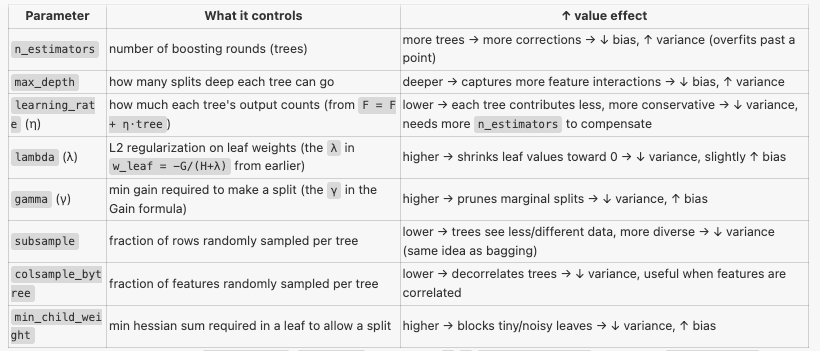

10. Hyperparameters (bias/variance):
    - n_estimators (# boosting rounds): more -> ↓bias, ↑variance
    - max_depth (how deep each tree splits): deeper -> ↓bias, ↑variance
    - learning_rate/η: lower -> ↓variance, needs more n_estimators to compensate
    - lambda/λ (L2 on leaf weights, same λ as w_leaf formula above): higher -> ↓variance, slightly ↑bias
    - gamma/γ (min gain to split, same γ as Gain formula above): higher -> ↓variance, ↑bias
    - subsample (fraction of rows per tree): lower -> ↓variance (trees see different data)
    - colsample_bytree (fraction of features per tree): lower -> ↓variance (decorrelates trees)
    - min_child_weight (min hessian sum to allow a split): higher -> ↓variance, ↑bias
    Underfitting: too few n_estimators, too shallow max_depth, λ/γ/min_child_weight too high
    Overfitting: too many n_estimators (no early stopping), too deep, λ/γ too low, subsample/colsample near 1.0

11. L1 (alpha) vs L2 (lambda) on leaf weight: L2 just adds to the denominator
    (w=-G/(H+λ), shrinks proportionally, never exactly 0); L1 soft-thresholds G
    toward 0 first (can zero out a leaf's weight entirely — sparser trees)

12. Why 2nd-order (Hessian), not just gradient like classic GBM: Taylor-expands
    the loss to 2nd order for a better local approximation -> faster convergence,
    and it's what makes the closed-form w_leaf/Gain formulas above possible
    (plain GBM needs a numeric line search instead). Also: XGBoost builds trees
    level-wise + supports parallel split-finding; classic GBM is more sequential.

13. Missing values: XGBoost doesn't need imputation — it learns a default split
    direction for missing values at each node during training (same mechanism
    that made enable_categorical's unseen-category handling work in the code below)

14. Not universally "best": on this project's sparse TF-IDF (2000 mostly-zero
    columns), logreg (0.96) beat XGBoost (0.93) — trees gain little from feature
    interactions that mostly aren't there in bag-of-words text. XGBoost's edge
    is structured/tabular features with real interactions (the 5 LLM-extracted
    fields), not sparse linear text signal.

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

cat_cols = ["contact_channel", "impersonated_entity", "payment_method_requested"]

# category dtype needed for enable_categorical splits below (raw strings won't work)
for split in [train_f, val_f, test_f]:
    for col in cat_cols:
        split[col] = split[col].astype("category")

# align category levels: val/test must use the exact same categories train saw
# if a category has a value in val that train never saw, 
# XGBoost needs to know about all possible categories upfront
# this locks val/test to train's exact category set, 
# treating anything unseen as a missing value rather than crashing.
# unseen -> treated as missing; XGBoost handles missing natively, no imputation
# (learns a default split direction per node, same mechanism either way)
for col in cat_cols:
    cats = train_f[col].cat.categories
    val_f[col] = val_f[col].cat.set_categories(cats)
    test_f[col] = test_f[col].cat.set_categories(cats)

feature_cols = cat_cols + ["urgency_language", "victim_sent_money"]
# 3 categorical + 2 boolean = 5 features, matches FEATURE_SCHEMA

le = LabelEncoder()
train_f["typology_enc"] = le.fit_transform(train_f["typology"])
val_f["typology_enc"] = le.transform(val_f["typology"])
# XGBoost needs int labels (0-9), same role as logreg's one-hot y


xgb = XGBClassifier(enable_categorical=True, tree_method="hist", random_state=42)
# - enable_categorical=True allows XGBoost to split directly on category values internally 
# instead of requiring one-hot columns  — hist is the tree method that supports this.
# defaults used (not tuned): n_estimators=100 (#rounds, ↑↓bias ↑variance),
# max_depth=6 (↑↓bias ↑variance), learning_rate/η=0.3 (↓↓variance, needs more rounds),
# lambda/λ=1 (L2 on leaf weight, ↑↓variance), gamma/γ=0 (min gain to split, ↑↓variance ↑bias)
# L1(alpha) vs L2(lambda): L2 shrinks proportionally (w=-G/(H+λ), never exactly 0);
# L1 soft-thresholds G toward 0 first (can zero out a leaf entirely)

xgb.fit(train_f[feature_cols], train_f["typology_enc"])
# fit() = boosting loop x n_estimators, once per class (10 parallel sequences):
# g=p-y, h=p(1-p)  [2nd-order/Hessian vs classic GBM's 1st-order -> faster convergence,
# via Taylor-expanding the loss -> enables closed-form w_leaf/Gain below]
# best split per node: Gain = ½[GL²/(HL+λ) + GR²/(HR+λ) - (GL+GR)²/(HL+HR+λ)] - γ
# leaf value: w = -G/(H+λ)
# update: F += η·w, repeated for every tree, every round, every class

xgb_preds = xgb.predict(val_f[feature_cols])
# predict() = final F per class -> softmax -> argmax, same ending as logreg
# NOT universally "best": logreg beat this on pure TF-IDF (0.96 vs 0.93, see below) —
# XGBoost's edge is feature interactions, weak on sparse bag-of-words text
print(classification_report(val_f["typology_enc"], xgb_preds))


              precision    recall  f1-score   support

           0       0.42      0.33      0.37        30
           1       0.82      0.90      0.86        30
           2       0.27      0.33      0.30        30
           3       0.91      1.00      0.95        30
           4       1.00      0.97      0.98        30
           5       0.18      0.20      0.19        30
           6       0.44      0.40      0.42        30
           7       0.47      0.47      0.47        30
           8       0.83      0.63      0.72        30
           9       0.97      1.00      0.98        30

    accuracy                           0.62       300
   macro avg       0.63      0.62      0.62       300
weighted avg       0.63      0.62      0.62       300



In [17]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(val_f["typology_enc"], xgb_preds)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df


,account_takeover,business_email_compromise,elder_financial_exploitation,family_emergency_scam,government_impersonation_scam,identity_theft,investment_scam,lottery_prize_scam,romance_scam,tech_support_scam
account_takeover,10,2,3,0,0,6,3,5,0,1
business_email_compromise,0,27,2,0,0,0,1,0,0,0
elder_financial_exploitation,0,1,10,3,0,7,3,4,2,0
family_emergency_scam,0,0,0,30,0,0,0,0,0,0
government_impersonation_scam,0,1,0,0,29,0,0,0,0,0
identity_theft,8,0,7,0,0,6,5,3,1,0
investment_scam,5,0,6,0,0,4,12,3,0,0
lottery_prize_scam,1,2,4,0,0,5,3,14,1,0
romance_scam,0,0,5,0,0,5,0,1,19,0
tech_support_scam,0,0,0,0,0,0,0,0,0,30


In [18]:
from scipy.sparse import hstack, csr_matrix

cat_encoded_train = train_f[["urgency_language", "victim_sent_money"]].astype(int).values
cat_encoded_val = val_f[["urgency_language", "victim_sent_money"]].astype(int).values

X_train_hybrid = hstack([X_train_tfidf, csr_matrix(cat_encoded_train), pd.get_dummies(train_f[cat_cols])])
X_val_hybrid = hstack([X_val_tfidf, csr_matrix(cat_encoded_val), pd.get_dummies(val_f[cat_cols]).reindex(columns=pd.get_dummies(train_f[cat_cols]).columns, fill_value=0)])

xgb_hybrid = XGBClassifier(tree_method="hist", random_state=42)
xgb_hybrid.fit(X_train_hybrid, train_f["typology_enc"])
hybrid_preds = xgb_hybrid.predict(X_val_hybrid)
print(classification_report(val_f["typology_enc"], hybrid_preds, target_names=le.classes_))


                               precision    recall  f1-score   support

             account_takeover       0.80      0.93      0.86        30
    business_email_compromise       1.00      0.97      0.98        30
 elder_financial_exploitation       0.86      0.80      0.83        30
        family_emergency_scam       0.97      1.00      0.98        30
government_impersonation_scam       1.00      1.00      1.00        30
               identity_theft       0.91      0.70      0.79        30
              investment_scam       0.97      1.00      0.98        30
           lottery_prize_scam       1.00      1.00      1.00        30
                 romance_scam       0.91      1.00      0.95        30
            tech_support_scam       1.00      1.00      1.00        30

                     accuracy                           0.94       300
                    macro avg       0.94      0.94      0.94       300
                 weighted avg       0.94      0.94      0.94       300



In [19]:
xgb_tfidf_only = XGBClassifier(tree_method="hist", random_state=42)
xgb_tfidf_only.fit(X_train_tfidf, train_f["typology_enc"])
tfidf_only_preds = xgb_tfidf_only.predict(X_val_tfidf)
print(classification_report(val_f["typology_enc"], tfidf_only_preds, target_names=le.classes_))


                               precision    recall  f1-score   support

             account_takeover       0.82      0.93      0.88        30
    business_email_compromise       1.00      0.97      0.98        30
 elder_financial_exploitation       0.79      0.77      0.78        30
        family_emergency_scam       0.97      0.97      0.97        30
government_impersonation_scam       1.00      1.00      1.00        30
               identity_theft       0.88      0.70      0.78        30
              investment_scam       0.97      1.00      0.98        30
           lottery_prize_scam       1.00      1.00      1.00        30
                 romance_scam       0.88      1.00      0.94        30
            tech_support_scam       1.00      0.97      0.98        30

                     accuracy                           0.93       300
                    macro avg       0.93      0.93      0.93       300
                 weighted avg       0.93      0.93      0.93       300



#### Findings — Modeling

- Baseline (logreg + TF-IDF): 0.96 accuracy

- LLM features alone (5 fields, XGBoost): 0.62 — badly confused on themes without
  a distinctive impersonated-entity signal (account_takeover, elder_financial_exploitation,
  identity_theft, investment_scam, lottery_prize_scam all bled into each other)

- Ablation, model held constant (XGBoost): TF-IDF alone 0.93 → TF-IDF + LLM features 0.94
  — real but modest +1pt lift, confirming LLM features augment text signal rather than
  replace it

- Logreg beat XGBoost on pure TF-IDF (0.96 vs 0.93) — expected: linear models tend to
  win on high-dimensional sparse bag-of-words text

- Caveat carried from data generation: synthetic narratives are fairly on-the-nose
  (generated directly from mechanic descriptions), so absolute accuracy numbers here
  are likely optimistic vs. real victim narratives

- Linear models tend to outperform tree-based models on high-dimensional sparse bag-of-words text, since a clean per-word weight is easier to learn than tree splits over 2000 sparse columns. 

- XGBoost being the wrong tool for pure TF-IDF, even though it's the right tool for the LLM-derived structured features.

 - XGBoost + TF-IDF only        → 0.93   (features: text only)
 - XGBoost + TF-IDF + LLM feats → 0.94   (features: text + LLM, model unchanged)
